# Multivariate Structure and Prediction in the Communities and Crime Dataset

**Course:** Multivariate Data Analysis  

**Author:** Sidharth Saha, Beckham Wee, Beckham Wee, Joe Wang

**Date:** [Date]

## 1. Introduction

### Research Question

What multivariate community-level patterns are associated with above-median violent crime, and how well can those patterns be used to predict `HighViolentCrime`?

### Purpose

This report presents a multivariate analysis of the **Communities and Crime** dataset from the UCI Machine Learning Repository. The goal is to study aggregate community-level associations among socioeconomic, demographic, housing, family-structure, urbanization, and violent-crime variables. The analysis applies multiple multivariate methods covered in the course—including PCA, factor analysis, CCA, clustering, Gaussian mixture models, classification, and regularization—to uncover structure in the data and build predictive models.

### Motivation

Understanding the multivariate structure of community-level characteristics and their statistical association with crime rates is relevant for social science, public policy research, and applied statistics. This dataset offers a rich, high-dimensional setting that motivates the use of dimension-reduction, latent-variable modeling, and supervised classification methods.

### Outcome Variables and Their Role in the Analysis

This project uses two related crime outcome variables:

- **`ViolentCrimesPerPop`**: A normalized continuous measure of per-capita violent crime. This variable is used mainly for exploratory analysis and for comparing average crime levels across PCA scores, factor scores, clusters, and Gaussian mixture components.

- **`HighViolentCrime`**: A derived binary label indicating whether `ViolentCrimesPerPop` is above the sample median. This variable is used as the supervised classification target for logistic regression, LDA, and regularized classification models.

The unsupervised methods in this report—PCA, factor analysis, CCA, clustering, hierarchical clustering, and Gaussian mixture models—are fit using predictor variables rather than the crime outcomes. The outcomes are then used afterward to interpret whether the multivariate structures discovered by these methods are associated with higher or lower violent-crime levels.

### Scope

The project applies the following methods:

- Principal Component Analysis (PCA)
- Factor Analysis
- Canonical Correlation Analysis (CCA)
- K-Means and Hierarchical Clustering
- Gaussian Mixture Models (GMM)
- Logistic Regression, LDA, and Regularized Classification (Ridge, Lasso, Elastic Net)

### Ethical Framing

This dataset is observational and measured at the community level, so the analysis focuses on associations, prediction, and multivariate structure rather than causal claims. Because some variables describe sensitive demographic characteristics, results are interpreted as aggregate community-level patterns and not as claims about individual behavior or group identity.

---
## 2. Data Description and Preprocessing

### Source and Context

The Communities and Crime dataset combines data from three sources:

- **1990 U.S. Census** — socioeconomic, demographic, housing, and family-structure variables.
- **1990 Law Enforcement Management and Administrative Statistics (LEMAS)** — police-force and law-enforcement variables.
- **1995 FBI Uniform Crime Report (UCR)** — violent crime rates.

Each observation represents a U.S. community. The predictor space includes variables measuring income, poverty, education, employment, race/ethnicity composition, housing characteristics, family structure, population density, urbanization, immigration, and law enforcement.

### Preprocessing Already Performed

1. **Identifier columns removed** — non-predictive community identifiers were dropped.
2. **High-missingness variables dropped** — any variable with more than 20% missing values was removed from the dataset.
3. **Median imputation** — remaining numeric missing values were imputed with the column median.
4. **Binary outcome derived** — `HighViolentCrime` was created by thresholding `ViolentCrimesPerPop` at the sample median.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
crime = pd.read_csv('datasets/communities_crime.csv')
df = crime.copy()
df.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,HighViolentCrime
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20,High
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67,High
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43,High
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12,Low
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03,Low


### Why Standardization Matters

The predictor variables are measured on different scales (e.g., percentages, counts, per-capita rates). Many multivariate methods—PCA, factor analysis, CCA, clustering, regularized regression—depend on covariance, correlation, or distance calculations. Without standardization, variables with larger numeric ranges would dominate. **All predictor variables should be standardized (zero mean, unit variance) before analysis.**

Table 2.1 summarizes the retained variables by thematic group. The “Representative Variables” column lists selected examples from each group rather than the full set of variables. Most predictors describe community-level socioeconomic status, education and employment, family structure, immigration and language, housing and residential stability, and urbanization. The dataset contains only one retained law-enforcement variable, `LemasPctOfficDrugUn`, likely because many original law-enforcement variables were removed during preprocessing due to missingness. `ViolentCrimesPerPop` is treated as the continuous outcome, while `HighViolentCrime` is the derived binary classification label.

In [3]:
df.columns.tolist()

['population',
 'householdsize',
 'racepctblack',
 'racePctWhite',
 'racePctAsian',
 'racePctHisp',
 'agePct12t21',
 'agePct12t29',
 'agePct16t24',
 'agePct65up',
 'numbUrban',
 'pctUrban',
 'medIncome',
 'pctWWage',
 'pctWFarmSelf',
 'pctWInvInc',
 'pctWSocSec',
 'pctWPubAsst',
 'pctWRetire',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'blackPerCap',
 'indianPerCap',
 'AsianPerCap',
 'OtherPerCap',
 'HispPerCap',
 'NumUnderPov',
 'PctPopUnderPov',
 'PctLess9thGrade',
 'PctNotHSGrad',
 'PctBSorMore',
 'PctUnemployed',
 'PctEmploy',
 'PctEmplManu',
 'PctEmplProfServ',
 'PctOccupManu',
 'PctOccupMgmtProf',
 'MalePctDivorce',
 'MalePctNevMarr',
 'FemalePctDiv',
 'TotalPctDiv',
 'PersPerFam',
 'PctFam2Par',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'PctWorkMomYoungKids',
 'PctWorkMom',
 'NumIlleg',
 'PctIlleg',
 'NumImmig',
 'PctImmigRecent',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecentImmig',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctSpeakEng

In [4]:
variable_groups = {
    "Population / Urbanization": [
        "population", "householdsize", "numbUrban", "pctUrban",
        "LandArea", "PopDens", "PctUsePubTrans"
    ],

    "Demographic Composition": [
        "racepctblack", "racePctWhite", "racePctAsian", "racePctHisp",
        "agePct12t21", "agePct12t29", "agePct16t24", "agePct65up"
    ],

    "Income / Poverty / Public Assistance": [
        "medIncome", "medFamInc", "perCapInc",
        "whitePerCap", "blackPerCap", "indianPerCap", "AsianPerCap",
        "OtherPerCap", "HispPerCap",
        "NumUnderPov", "PctPopUnderPov",
        "pctWWage", "pctWFarmSelf", "pctWInvInc",
        "pctWSocSec", "pctWPubAsst", "pctWRetire"
    ],

    "Education / Employment / Occupation": [
        "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
        "PctUnemployed", "PctEmploy",
        "PctEmplManu", "PctEmplProfServ",
        "PctOccupManu", "PctOccupMgmtProf"
    ],

    "Family Structure": [
        "MalePctDivorce", "MalePctNevMarr", "FemalePctDiv", "TotalPctDiv",
        "PersPerFam", "PctFam2Par", "PctKids2Par",
        "PctYoungKids2Par", "PctTeen2Par",
        "PctWorkMomYoungKids", "PctWorkMom",
        "NumIlleg", "PctIlleg"
    ],

    "Immigration / Language": [
        "NumImmig", "PctImmigRecent", "PctImmigRec5",
        "PctImmigRec8", "PctImmigRec10",
        "PctRecentImmig", "PctRecImmig5",
        "PctRecImmig8", "PctRecImmig10",
        "PctSpeakEnglOnly", "PctNotSpeakEnglWell",
        "PctForeignBorn"
    ],

    "Housing / Residential Stability": [
        "PctLargHouseFam", "PctLargHouseOccup",
        "PersPerOccupHous", "PersPerOwnOccHous", "PersPerRentOccHous",
        "PctPersOwnOccup", "PctPersDenseHous",
        "PctHousLess3BR", "MedNumBR",
        "HousVacant", "PctHousOccup", "PctHousOwnOcc",
        "PctVacantBoarded", "PctVacMore6Mos",
        "MedYrHousBuilt", "PctHousNoPhone", "PctWOFullPlumb",
        "OwnOccLowQuart", "OwnOccMedVal", "OwnOccHiQuart",
        "RentLowQ", "RentMedian", "RentHighQ",
        "MedRent", "MedRentPctHousInc",
        "MedOwnCostPctInc", "MedOwnCostPctIncNoMtg",
        "PctBornSameState", "PctSameHouse85",
        "PctSameCity85", "PctSameState85"
    ],

    "Shelter / Homelessness": [
        "NumInShelters", "NumStreet"
    ],

    "Law Enforcement": [
        "LemasPctOfficDrugUn"
    ],

    "Outcomes": [
        "ViolentCrimesPerPop", "HighViolentCrime"
    ]
}

variable_group_summary = pd.DataFrame([
    {
        "Variable Group": group,
        "Number of Variables": len(cols),
        "Representative Variables": ", ".join(cols[:5]) + ("..." if len(cols) > 5 else "")
    }
    for group, cols in variable_groups.items()
])

pd.set_option("display.max_colwidth", None)
variable_group_summary



,Variable Group,Number of Variables,Representative Variables
0,Population / Urbanization,7,"population, householdsize, numbUrban, pctUrban, LandArea..."
1,Demographic Composition,8,"racepctblack, racePctWhite, racePctAsian, racePctHisp, agePct12t21..."
2,Income / Poverty / Public Assistance,17,"medIncome, medFamInc, perCapInc, whitePerCap, blackPerCap..."
3,Education / Employment / Occupation,9,"PctLess9thGrade, PctNotHSGrad, PctBSorMore, PctUnemployed, PctEmploy..."
4,Family Structure,13,"MalePctDivorce, MalePctNevMarr, FemalePctDiv, TotalPctDiv, PersPerFam..."
5,Immigration / Language,12,"NumImmig, PctImmigRecent, PctImmigRec5, PctImmigRec8, PctImmigRec10..."
6,Housing / Residential Stability,31,"PctLargHouseFam, PctLargHouseOccup, PersPerOccupHous, PersPerOwnOccHous, PersPerRentOccHous..."
7,Shelter / Homelessness,2,"NumInShelters, NumStreet"
8,Law Enforcement,1,LemasPctOfficDrugUn
9,Outcomes,2,"ViolentCrimesPerPop, HighViolentCrime"


Table 2.2 confirms that the retained analysis dataset contains no remaining missing values after preprocessing. Variables with more than 20% missingness were removed before this stage, and remaining numeric missing values were median-imputed. As a result, all retained variables have a missing count of zero in the final modeling dataset.

In [5]:
missingness_report_table = pd.DataFrame({
    "Missingness Category": [
        "Variables with no missing values",
        "Variables with some missing values",
        "Variables with >20% missingness in retained dataset"
    ],
    "Number of Variables": [
        (df.isna().sum() == 0).sum(),
        (df.isna().sum() > 0).sum(),
        ((df.isna().mean() * 100) > 20).sum()
    ]
})

missingness_report_table

,Missingness Category,Number of Variables
0,Variables with no missing values,102
1,Variables with some missing values,0
2,Variables with >20% missingness in retained dataset,0


Table 2.3 reports the class balance for `HighViolentCrime`. Because the binary label was created using the sample median of `ViolentCrimesPerPop`, the two classes are approximately balanced: 993 communities are classified as high violent-crime communities and 1001 are classified as low violent-crime communities. This balanced split means that accuracy is more interpretable than it would be in a highly imbalanced setting, although later classification results should still report sensitivity, specificity, and ROC-AUC.

In [8]:
class_balance = (
    df["HighViolentCrime"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_balance["Proportion"] = (
    class_balance["Count"] / class_balance["Count"].sum()
).round(3)

class_balance

,Class,Count,Proportion
0,Low,1001,0.502
1,High,993,0.498


Figure 2.1 shows the distribution of `ViolentCrimesPerPop`, the continuous violent-crime outcome. The distribution is right-skewed, with many communities having relatively low values and a smaller number of communities having much higher values near the upper end of the normalized scale. The sample skewness is approximately 1.52, confirming a positive right tail. The dashed vertical line marks the sample median, approximately 0.150, which is used to define the binary outcome `HighViolentCrime`.

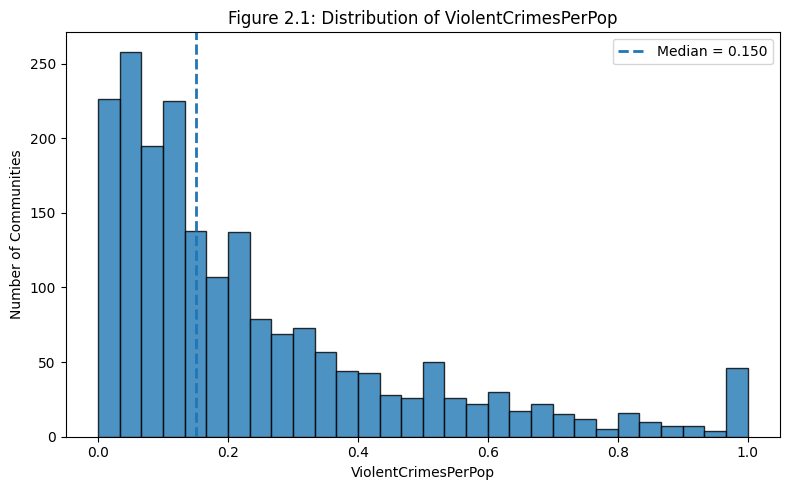

In [16]:
violent_crime = df["ViolentCrimesPerPop"]

median_crime = violent_crime.median()

plt.figure(figsize=(8, 5))
plt.hist(violent_crime, bins=30, edgecolor="black", alpha=0.8)
plt.axvline(median_crime, linestyle="--", linewidth=2, label=f"Median = {median_crime:.3f}")

plt.title("Figure 2.1: Distribution of ViolentCrimesPerPop")
plt.xlabel("ViolentCrimesPerPop")
plt.ylabel("Number of Communities")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
violent_crime_skewness = violent_crime.skew()
violent_crime_skewness

np.float64(1.522598485536617)

---
## 3. Exploratory Data Analysis

### Purpose

Understand the distributions, correlations, and broad associations among the variables before applying multivariate methods. EDA provides context for later analyses and helps identify potential issues (outliers, non-linearity, strong collinearity).

### Analyses

#### 3.1 Group-Level Summary Statistics

Table 3.1 computes group-level averages of the means, standard deviations, medians, and ranges for the normalized predictor variables within each thematic group. This provides a broad baseline summary of variable magnitude and spread across the retained predictor groups.

In [20]:
group_level_summary = []

for group, cols in predictor_groups.items():
    group_data = df[cols]

    group_level_summary.append({
        "Variable Group": group,
        "Number of Variables": len(cols),
        "Average Mean": group_data.mean().mean(),
        "Average Std. Dev.": group_data.std().mean(),
        "Average Median": group_data.median().mean(),
        "Overall Min": group_data.min().min(),
        "Overall Max": group_data.max().max()
    })

group_level_summary = pd.DataFrame(group_level_summary)

group_level_summary.round(3)

,Variable Group,Number of Variables,Average Mean,Average Std. Dev.,Average Median,Overall Min,Overall Max
0,Population / Urbanization,7,0.249,0.201,0.253,0.0,1.0
1,Demographic Composition,8,0.364,0.198,0.326,0.0,1.0
2,Income / Poverty / Public Assistance,17,0.348,0.187,0.312,0.0,1.0
3,Education / Employment / Occupation,9,0.399,0.196,0.369,0.0,1.0
4,Family Structure,13,0.474,0.182,0.473,0.0,1.0
5,Immigration / Language,12,0.285,0.211,0.239,0.0,1.0
6,Housing / Residential Stability,31,0.404,0.202,0.382,0.0,1.0
7,Shelter / Homelessness,2,0.026,0.102,0.000,0.0,1.0
8,Law Enforcement,1,0.094,0.240,0.000,0.0,1.0


#### 3.2 Distribution of the Violent Crime Outcome

Table 3.2 summarizes the continuous outcome `ViolentCrimesPerPop`. The mean value is 0.238, while the median is lower at 0.150, indicating that the distribution is right-skewed. This is also confirmed by the skewness value of 1.523 and by the boxplot, which shows several communities with unusually high violent-crime values relative to the rest of the sample.

The log-transformed histogram was used as a diagnostic check for skewness. Although the transformation compresses the upper tail, the main supervised analysis uses the binary outcome `HighViolentCrime`, so the continuous outcome is not transformed for the main classification models.

In [21]:
violent_crime = df["ViolentCrimesPerPop"]

crime_summary = pd.DataFrame({
    "Mean": [violent_crime.mean()],
    "Std. Dev.": [violent_crime.std()],
    "Median": [violent_crime.median()],
    "Min": [violent_crime.min()],
    "Max": [violent_crime.max()],
    "Skewness": [violent_crime.skew()]
})

crime_summary.round(3)

,Mean,Std. Dev.,Median,Min,Max,Skewness
0,0.238,0.233,0.15,0.0,1.0,1.523


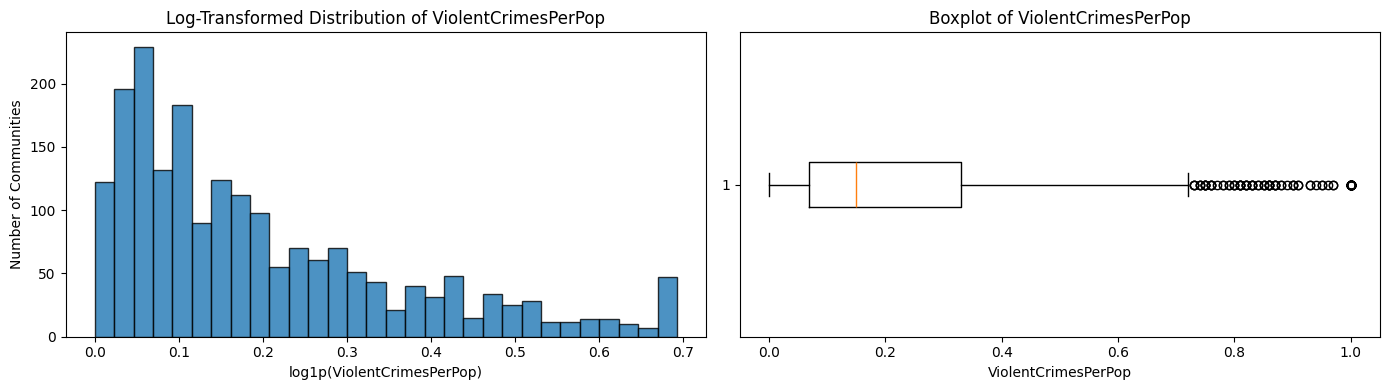

In [25]:
violent_crime = df["ViolentCrimesPerPop"]
violent_crime_log = np.log1p(violent_crime)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log-transformed histogram
axes[0].hist(violent_crime_log, bins=30, edgecolor="black", alpha=0.8)
axes[0].set_title("Log-Transformed Distribution of ViolentCrimesPerPop")
axes[0].set_xlabel("log1p(ViolentCrimesPerPop)")
axes[0].set_ylabel("Number of Communities")

# Boxplot of original outcome
axes[1].boxplot(violent_crime, vert=False)
axes[1].set_title("Boxplot of ViolentCrimesPerPop")
axes[1].set_xlabel("ViolentCrimesPerPop")

plt.tight_layout()
plt.show()

#### 3.3 Correlation Heatmap

Figure 3.3 shows the correlation structure for a representative subset of variables from the major thematic groups. The full predictor set is too large for a readable heatmap, so selected variables were chosen to cover the main categories in Table 2.1, including population, demographic composition, income, education, family structure, immigration/language, housing, and law enforcement.

The heatmap reveals clear blocks of correlated predictors, especially among income, poverty, education, family-structure, and housing variables. This multicollinearity motivates the use of PCA and factor analysis for dimension reduction, CCA for relationships between variable blocks, and regularized models for more stable prediction. `ViolentCrimesPerPop` is included only as a reference outcome.

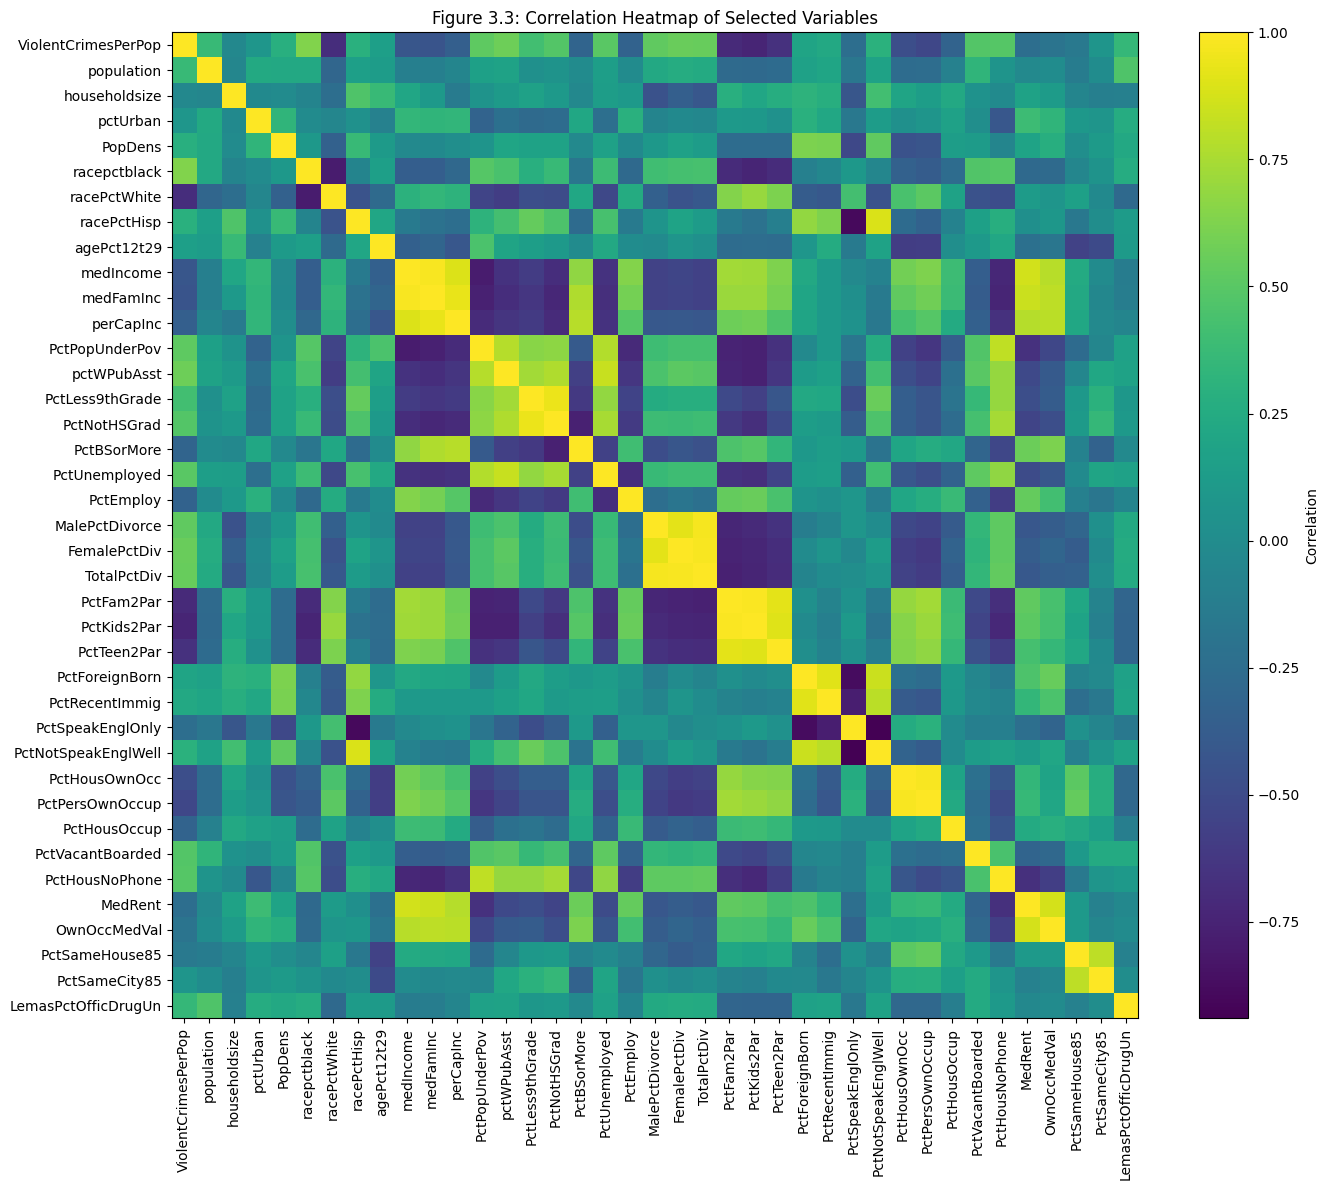

In [26]:
# Representative variables for readable correlation heatmap
heatmap_vars = [
    # Outcome
    "ViolentCrimesPerPop",

    # Population / urbanization
    "population", "householdsize", "pctUrban", "PopDens",

    # Demographic composition
    "racepctblack", "racePctWhite", "racePctHisp", "agePct12t29",

    # Income / poverty
    "medIncome", "medFamInc", "perCapInc", "PctPopUnderPov", "pctWPubAsst",

    # Education / employment
    "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
    "PctUnemployed", "PctEmploy",

    # Family structure
    "MalePctDivorce", "FemalePctDiv", "TotalPctDiv",
    "PctFam2Par", "PctKids2Par", "PctTeen2Par",

    # Immigration / language
    "PctForeignBorn", "PctRecentImmig",
    "PctSpeakEnglOnly", "PctNotSpeakEnglWell",

    # Housing / residential stability
    "PctHousOwnOcc", "PctPersOwnOccup", "PctHousOccup",
    "PctVacantBoarded", "PctHousNoPhone",
    "MedRent", "OwnOccMedVal",
    "PctSameHouse85", "PctSameCity85",

    # Law enforcement
    "LemasPctOfficDrugUn"
]

# Keep only variables that exist in the dataframe
heatmap_vars = [col for col in heatmap_vars if col in df.columns]

corr_matrix = df[heatmap_vars].corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Figure 3.3: Correlation Heatmap of Selected Variables")
plt.tight_layout()
plt.show()

#### 3.4 Boxplots: Low vs. High Violent-Crime Communities

Figure 3.4 compares selected normalized predictor variables between low and high violent-crime communities. High violent-crime communities tend to have lower median household income, lower owner-occupied housing, lower percentages of children in two-parent families, and lower bachelor’s degree attainment. They also tend to have higher poverty rates and somewhat higher population density. 

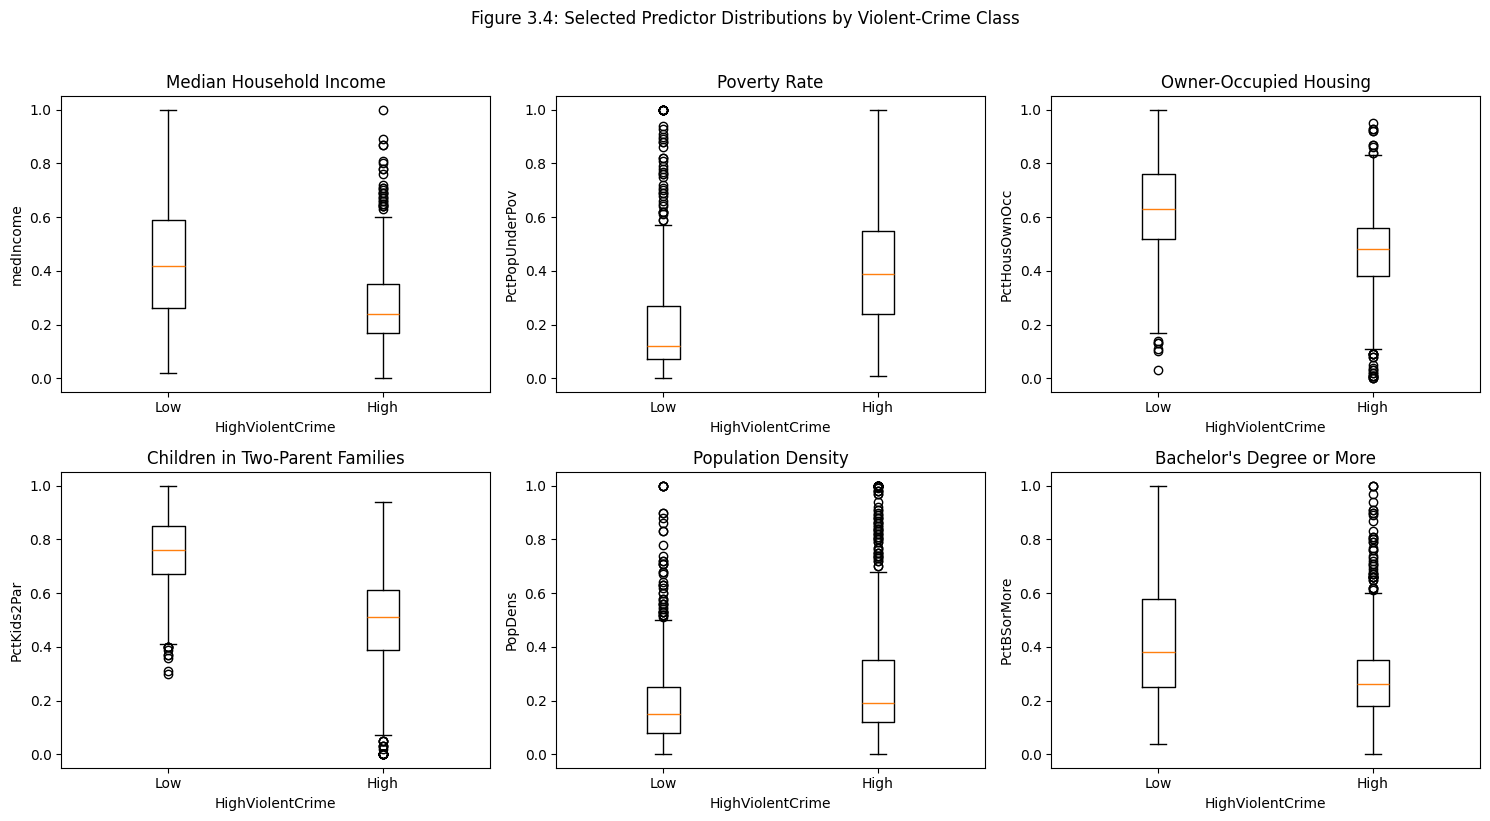

In [29]:
# Representative variables for low vs. high violent-crime comparison
boxplot_vars = {
    "medIncome": "Median Household Income",
    "PctPopUnderPov": "Poverty Rate",
    "PctHousOwnOcc": "Owner-Occupied Housing",
    "PctKids2Par": "Children in Two-Parent Families",
    "PopDens": "Population Density",
    "PctBSorMore": "Bachelor's Degree or More"
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (var, label) in zip(axes, boxplot_vars.items()):
    low_values = df[df["HighViolentCrime"] == "Low"][var]
    high_values = df[df["HighViolentCrime"] == "High"][var]
    
    ax.boxplot([low_values, high_values], tick_labels=["Low", "High"])
    ax.set_title(label)
    ax.set_xlabel("HighViolentCrime")
    ax.set_ylabel(var)

plt.suptitle("Figure 3.4: Selected Predictor Distributions by Violent-Crime Class", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. PCA: Dimension Reduction of the Full Predictor Space

### Purpose

Principal Component Analysis (PCA) finds orthogonal linear combinations of the standardized predictors that capture the most variance. With many correlated community-level variables, PCA provides low-dimensional summaries that can be visualized, interpreted, and used as inputs for downstream methods.

### Why PCA Is Appropriate Here

- The predictor space is high-dimensional with many inter-correlated variables.
- PCA reduces dimensionality while retaining maximal variance.
- PCA scores serve as inputs for clustering, GMM, and classification.
- PCA is **unsupervised** — it does not use the crime outcome.

### Analysis Plan

1. Run PCA on the standardized predictor matrix (excluding `ViolentCrimesPerPop` and `HighViolentCrime`).
2. Examine the eigenvalues, scree plot, and cumulative proportion of variance explained.
3. Select a number of components to retain (e.g., using the elbow rule or a cumulative-variance threshold such as 80%).
4. Examine the loadings for the top retained PCs.
5. Produce a score plot of PC1 vs. PC2, colored by `HighViolentCrime`.

### Planned Figures and Tables

- **Figure 4.1: Scree Plot** — Eigenvalues (or proportion of variance) vs. component number.

[Insert scree plot here]

- **Table 4.1: Cumulative Proportion of Variance Explained** — For the first 10–15 components.

[Insert cumulative variance table here]

- **Table 4.2: Loading Table for Top PCs** — Show the highest-magnitude loadings for each of the retained components. Highlight which variables load most strongly on each PC.

[Insert loading table here]

- **Figure 4.2: PC1 vs. PC2 Score Plot** — Scatterplot of community scores on PC1 and PC2, colored by `HighViolentCrime`.

[Insert score plot here]

### Interpretation Guidance

Interpret each retained PC based on which variables load most heavily. Possible interpretations include:

- **PC1**: Economic disadvantage / poverty (high loadings on poverty rate, low income, unemployment).
- **PC2**: Residential stability / housing ownership (high loadings on owner-occupied housing, housing age, residential tenure).
- **PC3**: Urbanization / density (high loadings on population density, population size).
- **PC4**: Family structure (high loadings on single-parent household rate, children in two-parent families).

These are descriptive labels for variance-maximizing directions. They do not represent causal constructs.

[Write detailed PC interpretation here]

### Cautionary Notes

- PCA is a variance-decomposition technique; the components are not latent factors in a generative sense.
- PCA is unsupervised: the separation visible in the score plot (if any) is not "built in" by the method — it reflects genuine multivariate structure that happens to align with the outcome.
- Component interpretations are subjective summaries of loading patterns, not definitive labels.

## 4. PCA: Dimension Reduction of the Full Predictor Space

### 4.1 PCA Workflow and Setup

PCA is used to summarize the high-dimensional predictor space into orthogonal components that capture major directions of variation. Following the course workflow, the PCA analysis proceeds in five steps: data diagnosis, preprocessing choice, PC-count selection, interpretation through loadings and scores, and robustness/limitations.

The PCA is fit only on the predictor variables, excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Although the retained variables are normalized to the 0–1 scale, they do not have equal variance, so correlation PCA is used by standardizing each predictor to mean 0 and standard deviation 1 before fitting PCA.

[Insert standardized predictor matrix code here]

In [42]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define outcome columns
outcome_cols = ["ViolentCrimesPerPop", "HighViolentCrime"]

# Predictor matrix only
X = df.drop(columns=outcome_cols)

# Standardize predictors for correlation PCA
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Quick checks
pca_setup_summary = pd.DataFrame({
    "Object": ["Original predictor matrix", "Standardized predictor matrix"],
    "Rows": [X.shape[0], X_scaled.shape[0]],
    "Columns": [X.shape[1], X_scaled.shape[1]],
    "Mean Check": [round(X.mean().mean(), 3), round(X_scaled.mean().mean(), 3)],
    "Std. Dev. Check": [round(X.std().mean(), 3), round(X_scaled.std().mean(), 3)]
})

pca_setup_summary

,Object,Rows,Columns,Mean Check,Std. Dev. Check
0,Original predictor matrix,1994,100,0.364,0.196
1,Standardized predictor matrix,1994,100,-0.000,1.000


The PCA setup table confirms that the analysis uses 100 predictor variables after excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Although the original predictors are normalized, their average standard deviation is only 0.196, meaning they do not have equal variance. After standardization, the predictors have approximately mean 0 and standard deviation 1, so the PCA is fit as correlation PCA.

### 4.2 Step 1: Data Diagnosis

Before fitting PCA, the dataset was checked for missingness, outcome distribution, and correlation structure. Table 2.2 confirms that the retained modeling dataset contains no remaining missing values after preprocessing. Figure 3.3 shows strong blocks of correlated predictors, especially among income, poverty, education, family-structure, and housing variables. This correlation structure supports the use of PCA because the predictors contain shared multivariate variation that can be summarized through lower-dimensional components.

### 4.3 Step 2: Preprocessing Choice — Correlation PCA

PCA can be fit either on the covariance matrix or the correlation matrix. Because the predictors represent different types of community characteristics and still have unequal variances after normalization, this analysis uses correlation PCA. This means each predictor is standardized before PCA so that the components reflect shared correlation structure rather than differences in variable spread.

The standardized predictor matrix from Section 4.1 is used for the PCA fit.

In [43]:
from sklearn.decomposition import PCA

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i+1}" for i in range(pca_scores.shape[1])],
    index=df.index
)

explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

pca_fit_summary = pd.DataFrame({
    "Number of Observations": [X_scaled.shape[0]],
    "Number of Predictors": [X_scaled.shape[1]],
    "Number of PCs Computed": [pca_scores_df.shape[1]],
    "Total Variance Explained": [round(explained_variance_ratio.sum(), 3)]
})

pca_fit_summary

,Number of Observations,Number of Predictors,Number of PCs Computed,Total Variance Explained
0,1994,100,100,1.0


The PCA fit uses 100 standardized predictor variables after excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Because all 100 PCs are computed, the total variance explained across the full set of components is 1.0, as expected. This confirms that the PCA model was fit correctly on the standardized predictor matrix.

### 4.4 Step 3: Choosing the Number of PCs

Figure 4.1 compares several criteria for choosing the number of principal components. The scree plot shows a steep decline in eigenvalues for the first several PCs, followed by a flatter region where additional components contribute less variance. The Kaiser rule retains PCs with eigenvalues greater than 1, while parallel analysis compares the observed eigenvalues to eigenvalues generated from random noise data of the same size.

These criteria do not need to give the same answer. The first few PCs are emphasized for interpretation because they explain the largest shares of variance and are most interpretable. A larger set of PCs may be retained for downstream clustering, GMM, and classification depending on the cumulative-variance and parallel-analysis results.

Figure 4.1 compares several criteria for choosing the number of PCs. The scree plot shows a steep decline in eigenvalues for the first several components, followed by a flatter region. The Kaiser rule retains 14 PCs, while parallel analysis suggests retaining 13 PCs because those observed eigenvalues exceed the random-data benchmark. The 80% cumulative-variance criterion requires 11 PCs. Taken together, these criteria suggest that roughly 11–14 PCs capture meaningful structure for downstream analysis, while the first four PCs are emphasized for interpretation because they explain the largest individual shares of variance.

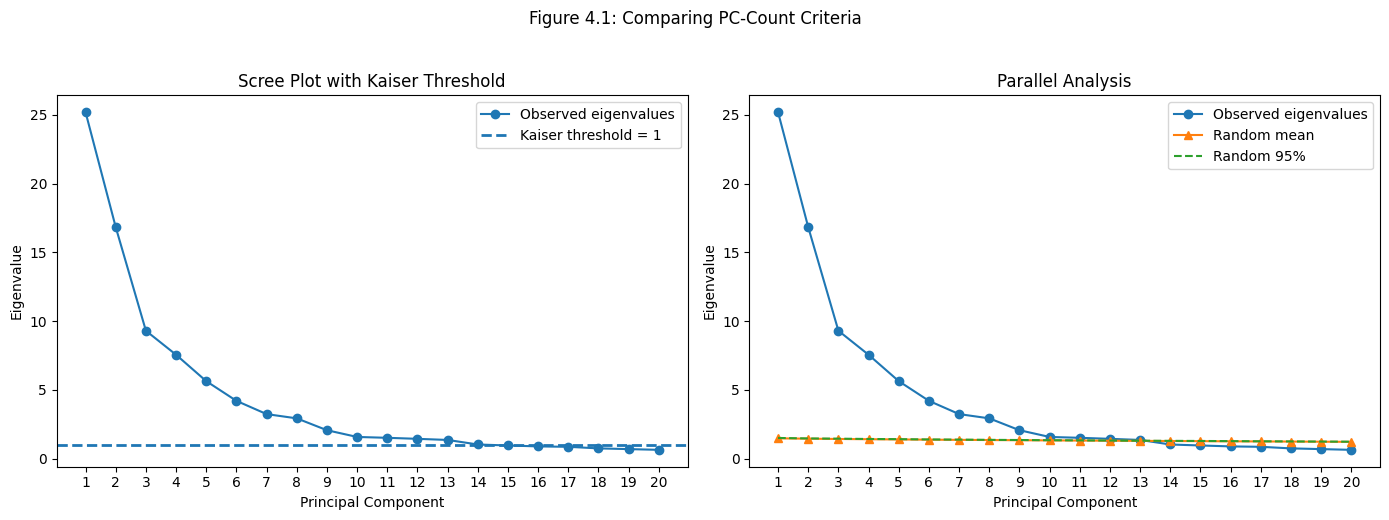

,Criterion,Number of PCs Suggested
0,80% cumulative variance,11
1,Kaiser rule: eigenvalue > 1,14
2,Parallel analysis: observed > random mean,13
3,Parallel analysis: observed > random 95%,13


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Observed PCA eigenvalues
observed_eigenvalues = explained_variance

# Kaiser rule
kaiser_pcs = (observed_eigenvalues > 1).sum()

# 80% cumulative variance rule
pcs_for_80 = (cumulative_variance < 0.80).sum() + 1

# Parallel analysis setup
n_simulations = 100
n_obs, n_vars = X_scaled.shape

random_eigenvalues = np.zeros((n_simulations, n_vars))

for i in range(n_simulations):
    random_data = np.random.normal(size=(n_obs, n_vars))
    random_pca = PCA().fit(random_data)
    random_eigenvalues[i, :] = random_pca.explained_variance_

random_mean = random_eigenvalues.mean(axis=0)
random_95 = np.percentile(random_eigenvalues, 95, axis=0)

# Parallel analysis rule
parallel_mean_pcs = (observed_eigenvalues > random_mean).sum()
parallel_95_pcs = (observed_eigenvalues > random_95).sum()

# Display first 20 PCs in plots
max_pc_plot = 20
pc_numbers = np.arange(1, max_pc_plot + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot with Kaiser threshold
axes[0].plot(
    pc_numbers,
    observed_eigenvalues[:max_pc_plot],
    marker="o",
    label="Observed eigenvalues"
)

axes[0].axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Kaiser threshold = 1"
)

axes[0].set_title("Scree Plot with Kaiser Threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_xticks(pc_numbers)
axes[0].legend()

# Parallel analysis plot
axes[1].plot(
    pc_numbers,
    observed_eigenvalues[:max_pc_plot],
    marker="o",
    label="Observed eigenvalues"
)

axes[1].plot(
    pc_numbers,
    random_mean[:max_pc_plot],
    marker="^",
    label="Random mean"
)

axes[1].plot(
    pc_numbers,
    random_95[:max_pc_plot],
    linestyle="--",
    label="Random 95%"
)

axes[1].set_title("Parallel Analysis")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_xticks(pc_numbers)
axes[1].legend()

plt.suptitle("Figure 4.1: Comparing PC-Count Criteria", y=1.03)
plt.tight_layout()
plt.show()

pc_count_summary = pd.DataFrame({
    "Criterion": [
        "80% cumulative variance",
        "Kaiser rule: eigenvalue > 1",
        "Parallel analysis: observed > random mean",
        "Parallel analysis: observed > random 95%"
    ],
    "Number of PCs Suggested": [
        pcs_for_80,
        kaiser_pcs,
        parallel_mean_pcs,
        parallel_95_pcs
    ]
})

pc_count_summary

### 4.5 Step 4: Interpreting PC Loadings

PC loadings show which original variables contribute most strongly to each principal component. Table 4.2 reports the ten highest-magnitude loadings for the first four PCs. Although the PC-count criteria suggest retaining roughly 11–14 PCs for downstream analysis, the loading interpretation focuses on the first four PCs because they explain the largest individual shares of variance and have the clearest loading patterns.

The signs of the loadings are interpreted relatively. Flipping the sign of a PC would not change the underlying component, so the interpretation focuses on which variables move together or in opposite directions.

**PC1: Economic advantage / family stability.**  
PC1 has positive loadings on `medFamInc`, `medIncome`, `perCapInc`, `PctKids2Par`, `PctFam2Par`, and `PctYoungKids2Par`, and negative loadings on `PctPopUnderPov`, `pctWPubAsst`, and `PctHousNoPhone`. This component contrasts communities with higher income and stronger two-parent family structure against communities with higher poverty, public assistance, and housing disadvantage.

**PC2: Immigration / language composition.**  
PC2 has high positive loadings on recent immigration variables such as `PctRecImmig10`, `PctRecImmig8`, `PctRecImmig5`, `PctRecentImmig`, and `PctForeignBorn`, along with a negative loading on `PctSpeakEnglOnly`. This component mainly captures variation related to immigration recency, foreign-born population share, and language patterns.

**PC3: Household size / occupancy structure.**  
PC3 loads strongly on `PersPerOccupHous`, `PersPerFam`, `PersPerOwnOccHous`, `householdsize`, `PersPerRentOccHous`, and large-household variables. This component describes household size and occupancy intensity, with larger household and family structures on the positive side.

**PC4: Residential stability and age composition.**  
PC4 has positive loadings on `PctSameCity85`, `PctSameHouse85`, `agePct65up`, and `pctWSocSec`, and negative loadings on younger age-share variables such as `agePct12t29`, `agePct16t24`, and `agePct12t21`. This component contrasts older, more residentially stable communities with younger, more mobile communities.

In [46]:
# PCA loadings for all components
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

# Side-by-side top loading table for first 4 PCs
top_n = 10
pcs_to_interpret = ["PC1", "PC2", "PC3", "PC4"]

side_by_side_loadings = pd.DataFrame()

for pc in pcs_to_interpret:
    pc_loadings = loadings[[pc]].copy()
    pc_loadings["Abs Loading"] = pc_loadings[pc].abs()
    pc_loadings = pc_loadings.sort_values("Abs Loading", ascending=False).head(top_n)
    
    pc_table = pd.DataFrame({
        f"{pc} Variable": pc_loadings.index,
        f"{pc} Loading": pc_loadings[pc].round(3).values
    })
    
    side_by_side_loadings = pd.concat(
        [side_by_side_loadings, pc_table.reset_index(drop=True)],
        axis=1
    )

side_by_side_loadings

,PC1 Variable,PC1 Loading,PC2 Variable,PC2 Loading,PC3 Variable,PC3 Loading,PC4 Variable,PC4 Loading
0,medFamInc,0.183,PctRecImmig10,0.219,PersPerOccupHous,0.254,PctSameCity85,0.260
1,medIncome,0.182,PctRecImmig8,0.219,PersPerFam,0.232,agePct12t29,-0.254
2,PctKids2Par,0.175,PctRecImmig5,0.217,PersPerOwnOccHous,0.224,PctSameHouse85,0.246
3,pctWInvInc,0.174,PctRecentImmig,0.214,householdsize,0.223,agePct16t24,-0.243
4,PctPopUnderPov,-0.173,PctForeignBorn,0.213,PersPerRentOccHous,0.203,agePct12t21,-0.240
5,PctFam2Par,0.172,PctSpeakEnglOnly,-0.191,PctLargHouseOccup,0.201,agePct65up,0.200
6,PctYoungKids2Par,0.171,PctNotSpeakEnglWell,0.188,HousVacant,-0.170,pctWSocSec,0.191
7,perCapInc,0.169,PctPersDenseHous,0.175,PctLargHouseFam,0.169,PctImmigRec5,-0.180
8,pctWPubAsst,-0.164,racePctAsian,0.167,numbUrban,-0.151,PctImmigRecent,-0.178
9,PctHousNoPhone,-0.164,racePctHisp,0.162,population,-0.149,PctImmigRec8,-0.176


### 4.6 Step 5: Interpreting PC Scores

PC scores show where each community falls along the principal component directions. Figure 4.2 plots the first two PC scores and colors each community by `HighViolentCrime` to assess whether the unsupervised PCA structure aligns with the binary outcome.

The clearest separation appears along PC1. Low violent-crime communities are more concentrated on the positive side of PC1, while high violent-crime communities are more concentrated on the negative side. Based on the PC1 loadings, this suggests that the economic advantage / family stability dimension is strongly associated with the violent-crime label.

PC2 shows greater overlap between the two classes, suggesting that the immigration/language composition dimension does not separate high and low violent-crime communities as clearly in this two-dimensional view. Because PCA was fit without using `HighViolentCrime`, this pattern reflects an association between the predictor structure and the outcome, not a supervised classification result.

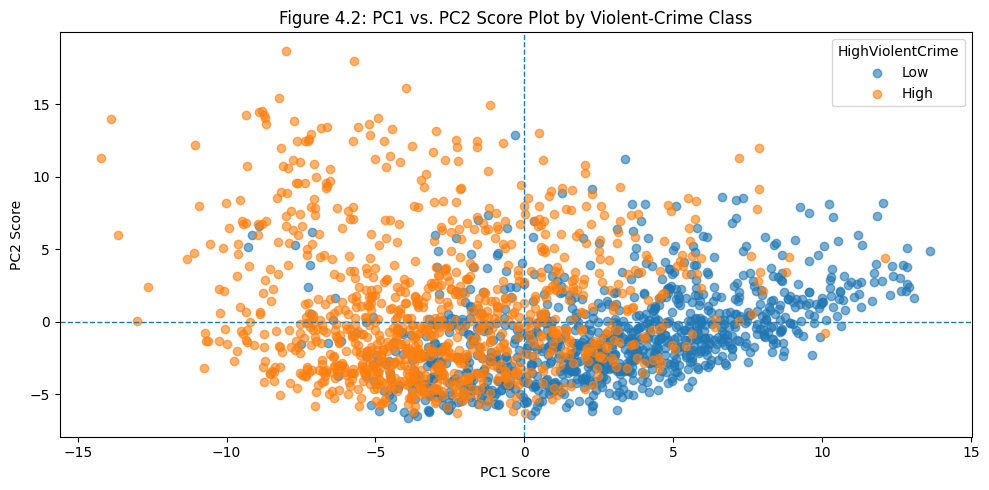

In [50]:
import matplotlib.pyplot as plt

# Combine PCA scores with violent-crime class label
pca_plot_df = pca_scores_df[["PC1", "PC2"]].copy()
pca_plot_df["HighViolentCrime"] = df["HighViolentCrime"]

plt.figure(figsize=(10, 5))

for label in ["Low", "High"]:
    subset = pca_plot_df[pca_plot_df["HighViolentCrime"] == label]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=label
    )

plt.axhline(0, linewidth=1, linestyle="--")
plt.axvline(0, linewidth=1, linestyle="--")

plt.title("Figure 4.2: PC1 vs. PC2 Score Plot by Violent-Crime Class")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.legend(title="HighViolentCrime")
plt.tight_layout()
plt.show()

### 4.7 PCA Summary and Use in Later Sections

PCA reduced the 100 standardized predictors into a smaller set of orthogonal summaries. The first two PCs explain 42.0% of the total variance, the first five explain 64.5%, and the first eleven explain approximately 80.0%. Kaiser and parallel analysis suggest retaining about 13–14 PCs, so the later clustering, GMM, and classification sections will use a retained PC-score matrix rather than all 100 original predictors.

For interpretation, only the first four PCs are labeled: PC1 captures economic advantage/family stability, PC2 captures immigration/language composition, PC3 captures household and occupancy structure, and PC4 captures residential stability/age composition. The PC1 score plot also shows clear alignment with `HighViolentCrime`, with high violent-crime communities concentrated more on the lower-PC1 side.

---
## 5. Factor Analysis: Latent Community Structure

### Purpose

Factor Analysis (FA) complements PCA by modeling the observed covariance matrix as a product of latent factors plus variable-specific uniqueness terms. While PCA decomposes total variance, FA explicitly models shared variance through latent constructs, providing a different lens on the data's structure.

### Why Factor Analysis Complements PCA

| Aspect | PCA | Factor Analysis |
|--------|-----|----------------|
| Goal | Maximize variance explained | Model shared covariance via latent factors |
| Model | Linear combinations of observed variables | Observed variables as functions of latent factors + uniqueness |
| Rotation | Orthogonal components (by construction) | Factors can be rotated (varimax, promax) for interpretability |
| Uniqueness | Not modeled separately | Each variable has a uniqueness term |

### Planned Latent Constructs

Based on domain knowledge and the correlation structure, plausible latent factors include:

- **Economic Disadvantage** — poverty, low income, unemployment, low education.
- **Housing Stability** — owner-occupied housing, housing age, residential tenure, vacancy rates.
- **Family Structure** — single-parent households, children in two-parent families, household size.
- **Urbanization / Mobility** — population density, population size, recent immigration, geographic mobility.

### Analysis Plan

1. Determine the number of factors to extract using the scree plot, parallel analysis, or information criteria.
2. Fit the factor model using maximum likelihood or principal axis factoring.
3. Apply rotation (varimax for orthogonal, promax for oblique) to improve interpretability.
4. Examine the rotated factor loadings.
5. Compute factor scores for each community.
6. Compare factor scores across `HighViolentCrime` groups.

### Planned Figures and Tables

- **Figure 5.1: Parallel Analysis / Scree Plot for Factor Selection**

[Insert factor selection plot here]

- **Table 5.1: Rotated Factor Loadings** — Show loadings of each variable on each retained factor. Highlight loadings above a threshold (e.g., |loading| > 0.4).

[Insert rotated loading table here]

- **Table 5.2: Factor Interpretation Summary** — Name each factor, list its key high-loading variables, and provide a descriptive label.

[Insert factor interpretation table here]

- **Figure 5.2: Factor Scores by `HighViolentCrime`** — Boxplots or violin plots of each factor score, split by the binary outcome.

[Insert factor score comparison plot here]

### Interpretation Guidance

[Write interpretation here — describe each factor in terms of its loading pattern and what community characteristic it represents. Compare with PCA results: do similar themes emerge? Note which factors show the largest separation between high and low violent-crime communities.]

### Cautionary Notes

- Factors are **statistical summaries** of shared covariance, not causal mechanisms.
- The choice of rotation affects the loading pattern. Report which rotation was used and why.
- Factor labels are interpretive conveniences; they reflect the analyst's reading of the loadings, not ground-truth constructs.

---
## 6. CCA: Association Between Variable Blocks

### Purpose

Canonical Correlation Analysis (CCA) studies the relationship between two blocks of variables by finding paired linear combinations (canonical variates) that have maximum correlation with each other. CCA reveals how one set of community characteristics is associated with another set, without designating either block as a "response."

### Block Definitions

**Primary block pairing:**

- **Block X (Socioeconomic and Education):** Variables such as median household income, per-capita income, poverty rate, unemployment rate, percent with bachelor's degree, percent with less than high-school education.
- **Block Y (Housing, Family, Population, and Urbanization):** Variables such as percent owner-occupied housing, median rent, vacancy rate, percent single-parent households, population density, population size, percent urban.

**Alternative block pairing (if the primary has too many variables for stable estimation):**

- **Block X (Economic Disadvantage):** Poverty rate, median income, unemployment rate, percent below poverty line.
- **Block Y (Residential Stability / Family Structure):** Owner-occupied housing rate, residential tenure, single-parent household rate, household size.

### Important Framing

- CCA studies **association** between variable blocks, not prediction and not causation.
- Avoid placing sensitive demographic variables as the central block whose association with crime is being examined. Instead, use socioeconomic and structural variables.
- The canonical variates describe **joint linear patterns** across the two blocks.

### Analysis Plan

1. Standardize all variables in both blocks.
2. Compute canonical correlations and test their significance.
3. Examine the canonical loadings (or canonical structure correlations) for the first one or two canonical pairs.
4. Produce a scatterplot of the first canonical variate pair.

### Planned Figures and Tables

- **Table 6.1: Canonical Correlations** — Report the canonical correlations for each pair, along with significance tests (Wilks' lambda or similar).

[Insert canonical correlations table here]

- **Table 6.2: Canonical Loadings for the First Two Pairs** — Show how each original variable in Block X and Block Y loads on the first and second canonical variates.

[Insert canonical loadings table here]

- **Figure 6.1: First Canonical Variate Scatterplot** — Plot the first canonical variate from Block X against the first canonical variate from Block Y, colored by `HighViolentCrime`.

[Insert canonical variate scatterplot here]

### Interpretation Guidance

[Write interpretation here — describe what each side of the first canonical pair represents. For example: "The first canonical variate from Block X captures an economic disadvantage gradient, while the first variate from Block Y captures a residential instability pattern. Their high correlation indicates that communities with greater economic disadvantage tend to also exhibit lower residential stability."]

### Cautionary Notes

- CCA finds the **maximum** linear association, which may not represent the full or only relationship between the blocks.
- Canonical correlations can be inflated in small samples relative to the number of variables. Report the ratio of observations to variables.
- Results describe association, not directionality or causation.

---
## 7. Clustering: Hard Community Profiles

### Purpose

Clustering is an unsupervised method that groups observations based on multivariate similarity. Applied to community data, clustering can reveal "latent community profiles" — groups of communities that share similar patterns of socioeconomic, housing, family, and urbanization characteristics.

### Input Strategy

Rather than clustering on the full high-dimensional predictor space (which suffers from the curse of dimensionality and noise), use **PCA scores or factor scores** as inputs. This reduces noise, removes collinearity, and makes distance-based methods more reliable.

### Methods

#### 7.1 K-Means Clustering

- Partition communities into *K* clusters by minimizing within-cluster sum of squares.
- Select *K* using the elbow method and silhouette analysis.

#### 7.2 Hierarchical Clustering

- Build a hierarchy of nested clusters using agglomerative methods (e.g., Ward's linkage).
- Use the dendrogram to visualize the merging structure and choose a cut level.

### Analysis Plan

1. Cluster on the retained PCA scores (or factor scores).
2. Evaluate cluster quality using the elbow plot and silhouette scores for K-means.
3. Produce a dendrogram for hierarchical clustering.
4. For the chosen number of clusters, create a cluster profile table.
5. Compare clusters by their mean values of PC/factor scores and by the mean `ViolentCrimesPerPop` and proportion of `HighViolentCrime`.

### Planned Figures and Tables

- **Figure 7.1: Elbow Plot** — Within-cluster sum of squares vs. number of clusters.

[Insert elbow plot here]

- **Figure 7.2: Silhouette Scores** — Average silhouette width vs. number of clusters.

[Insert silhouette plot here]

- **Figure 7.3: Dendrogram** — Hierarchical clustering dendrogram (Ward's linkage).

[Insert dendrogram here]

- **Table 7.1: Cluster Profile Table** — For each cluster, report:
  - Number of communities
  - Mean values of top PC or factor scores
  - Mean `ViolentCrimesPerPop`
  - Proportion with `HighViolentCrime = 1`

[Insert cluster profile table here]

- **Figure 7.4: Cluster Visualization in PC Space** — Scatterplot of PC1 vs. PC2 colored by cluster membership.

[Insert cluster visualization here]

### Interpretation Guidance

[Write interpretation here — describe each cluster as a "community profile." For example: "Cluster 1 contains communities with high scores on the economic disadvantage component and low scores on residential stability, and it has the highest average violent crime rate. Cluster 3 contains affluent, low-density communities with the lowest crime rates."]

### Cautionary Notes

- Clusters are **modeling summaries**, not ground-truth categories. The number and composition of clusters depend on the method, distance metric, and number of components used.
- K-means assumes spherical clusters of roughly equal size; real data may not satisfy this.
- Cluster labels (e.g., "disadvantaged urban" or "stable suburban") are interpretive labels assigned by the analyst.

---
## 8. Gaussian Mixture Models: Probabilistic Community Profiles

### Purpose

Gaussian Mixture Models (GMMs) extend clustering by modeling the data as a mixture of multivariate Gaussian distributions. Each community receives **soft (probabilistic) assignments** across components, allowing for uncertainty in group membership. GMMs also permit **elliptical cluster shapes**, accommodating different covariance structures across groups.

### Why GMM Extends K-Means

| Aspect | K-Means | GMM |
|--------|---------|-----|
| Assignments | Hard (each point belongs to exactly one cluster) | Soft (probability of belonging to each component) |
| Cluster shape | Spherical (equal variance assumption) | Elliptical (each component has its own covariance) |
| Estimation | Minimize within-cluster sum of squares | Maximize likelihood via EM algorithm |
| Model selection | Elbow / silhouette | BIC / AIC |

### Analysis Plan

1. Fit GMMs on the retained PCA scores (or factor scores) for varying numbers of components (e.g., 2 through 8).
2. Select the number of components using BIC and/or AIC.
3. Examine component membership probabilities.
4. Compare GMM components by average `ViolentCrimesPerPop` and proportion of `HighViolentCrime`.
5. Compare GMM results with K-means clusters for the same number of groups.

### Planned Figures and Tables

- **Figure 8.1: BIC/AIC Across Number of Components** — Line plot showing BIC and AIC for different numbers of GMM components.

[Insert BIC/AIC plot here]

- **Table 8.1: GMM Component Summary** — For each component, report:
  - Number of communities assigned (by maximum probability)
  - Mean PC/factor scores
  - Mean `ViolentCrimesPerPop`
  - Proportion `HighViolentCrime = 1`

[Insert GMM component summary table here]

- **Figure 8.2: GMM Components in PC Space** — Scatterplot of PC1 vs. PC2 colored by most-likely GMM component, with ellipses representing component covariance.

[Insert GMM visualization here]

- **Table 8.2: K-Means vs. GMM Comparison** — Cross-tabulation of K-means cluster labels and GMM component labels. Report agreement metrics (e.g., adjusted Rand index).

[Insert comparison table here]

### Interpretation Guidance

[Write interpretation here — describe GMM components as "probabilistic community profiles." Note whether the GMM identifies similar groupings to K-means or reveals additional nuance through soft assignments and non-spherical clusters. Comment on whether components with high crime rates differ systematically from low-crime components in their multivariate profiles.]

### Cautionary Notes

- GMM components are statistical constructs, not real population subgroups.
- The EM algorithm can converge to local optima; consider running multiple initializations.
- BIC tends to favor simpler models than AIC. Report both and justify the choice.

---
## 9. Classification: Predicting HighViolentCrime

### Purpose

This section shifts from unsupervised exploration to **supervised prediction**. The goal is to predict the binary outcome `HighViolentCrime` using the multivariate summaries and raw predictors developed in earlier sections.

### Outcome

`HighViolentCrime` (1 = above-median violent crime, 0 = at or below median).

### Candidate Models

1. **Logistic Regression on Original Standardized Predictors** — Baseline full model.
2. **Logistic Regression on PCA Scores** — Uses dimension-reduced inputs; avoids multicollinearity.
3. **Logistic Regression on Factor Scores** — Uses latent factor summaries as predictors.
4. **Linear Discriminant Analysis (LDA)** — On PCA or factor scores; assumes equal covariance across classes.
5. **Regularized Logistic Regression** — Ridge, lasso, or elastic net on original predictors (see Section 10).

### Optional Feature Comparison

Consider adding cluster labels (from K-means) or GMM component responsibilities as additional predictors to evaluate whether unsupervised groupings improve classification.

### Evaluation Plan

- Use a **train/test split** (e.g., 70/30 or 80/20) or **k-fold cross-validation** (e.g., 10-fold).
- Report the following metrics on the test set (or averaged across folds):
  - **Confusion matrix**
  - **Accuracy**
  - **Sensitivity** (true positive rate)
  - **Specificity** (true negative rate)
  - **ROC-AUC**

### Planned Figures and Tables

- **Table 9.1: Classification Results Summary** — One row per model, columns for accuracy, sensitivity, specificity, and AUC.

[Insert classification results table here]

- **Figure 9.1: ROC Curves** — Overlay ROC curves for all candidate models on one plot.

[Insert ROC curve plot here]

- **Table 9.2: Confusion Matrix for Best Model** — Show the confusion matrix for the best-performing model.

[Insert confusion matrix here]

### Interpretation Guidance

[Write interpretation here — compare models. Which input representation (raw predictors, PCA scores, factor scores) yields the best prediction? Does regularization improve over unpenalized logistic regression? Does adding cluster/GMM features help?]

### Cautionary Notes

- **Threshold choice matters.** The default 0.5 threshold may not optimize sensitivity or specificity. Report results at the default threshold but discuss threshold sensitivity.
- **Accuracy alone may be misleading**, especially if the class balance is not exactly 50/50 after splitting.
- Predictive performance does not imply causal understanding. A model that predicts well may rely on proxies or confounded associations.

---
## 10. Regularization and High-Dimensional Concerns

### Purpose

Regularization addresses problems that arise when fitting models with many correlated predictors: coefficient instability, overfitting, and unreliable variable importance estimates. This section discusses and applies regularized logistic regression methods.

### Why Regularization Is Relevant

- The dataset contains many predictors, several of which are highly correlated.
- Ordinary logistic regression coefficients can be unstable and have high variance when predictors are collinear.
- Regularization shrinks coefficients toward zero, trading a small increase in bias for a large reduction in variance.

### Methods

| Method | Penalty | Effect |
|--------|---------|--------|
| **Ridge** (L2) | Sum of squared coefficients | Shrinks all coefficients; stabilizes correlated predictors; no variable selection |
| **Lasso** (L1) | Sum of absolute coefficients | Shrinks some coefficients exactly to zero; performs variable selection |
| **Elastic Net** | Weighted combination of L1 and L2 | Balances sparsity (lasso) and stability (ridge); handles groups of correlated variables |

### Analysis Plan

1. Fit ridge, lasso, and elastic net logistic regression on the original standardized predictors.
2. Use cross-validation to select the regularization parameter (lambda).
3. Compare predictive performance (accuracy, AUC) with unpenalized logistic regression.
4. For lasso and elastic net, examine which variables are retained (non-zero coefficients).
5. Compare the set of selected variables with the high-loading variables from PCA and factor analysis.

### Planned Figures and Tables

- **Figure 10.1: Cross-Validation Curve** — Plot cross-validated log-loss or AUC as a function of lambda for lasso or elastic net.

[Insert CV curve here]

- **Table 10.1: Non-Zero Coefficients from Lasso/Elastic Net** — List the variables retained by the sparse model and their coefficient values.

[Insert coefficient table here]

- **Table 10.2: Regularized vs. Unpenalized Performance** — Compare accuracy, AUC, and number of predictors used.

[Insert performance comparison table here]

### Interpretation Guidance

[Write interpretation here — note that variables selected by lasso are "predictively important" within the model, not necessarily causally important. Compare the lasso-selected variables with the PCA/factor loading patterns. Do the same themes (economic disadvantage, housing stability, family structure) emerge?]

### Cautionary Notes

- **Selected variables are predictive associations, not causal drivers.** A variable retained by lasso may be predictive because it is a proxy for other unmeasured factors.
- When predictors are highly correlated, lasso may arbitrarily select one from a group while setting others to zero. Ridge or elastic net may be more appropriate for stable coefficient estimation.
- The regularization path depends on the scaling of predictors; standardization is essential.

---
## 11. Model Comparison and Synthesis

### Purpose

Synthesize the results from all preceding sections into a unified summary. This section connects the multivariate methods to each other and draws overarching conclusions about the dataset's structure and predictive patterns.

### Planned Comparison Table

**Table 11.1: Summary of All Methods**

| Method | Course Concept | Input Variables | Output | Main Insight | Limitation |
|--------|---------------|-----------------|--------|-------------|------------|
| PCA | Dimension reduction | Standardized predictors | Principal components | [Fill in] | [Fill in] |
| Factor Analysis | Latent variable modeling | Standardized predictors | Latent factor scores | [Fill in] | [Fill in] |
| CCA | Association between variable blocks | Two predictor blocks | Canonical variates & correlations | [Fill in] | [Fill in] |
| K-Means | Unsupervised clustering | PCA/factor scores | Hard cluster labels | [Fill in] | [Fill in] |
| Hierarchical Clustering | Unsupervised clustering | PCA/factor scores | Dendrogram & cluster labels | [Fill in] | [Fill in] |
| GMM | Probabilistic clustering (EM) | PCA/factor scores | Soft component memberships | [Fill in] | [Fill in] |
| Logistic Regression | Classification | Various input sets | Predicted class & probabilities | [Fill in] | [Fill in] |
| LDA | Classification | PCA/factor scores | Predicted class | [Fill in] | [Fill in] |
| Ridge / Lasso / Elastic Net | Regularized classification | Standardized predictors | Predicted class & selected variables | [Fill in] | [Fill in] |

[Complete the table after all analyses are run]

### Synthesis Questions

Address the following questions in the synthesis narrative:

1. **What multivariate structures appear repeatedly?** Do PCA, factor analysis, and CCA consistently highlight the same underlying themes (e.g., economic disadvantage, housing stability, family structure, urbanization)?

2. **Do PCA/factor scores separate high vs. low violent-crime communities?** How much separation is visible in the score plots? Which components or factors are most discriminating?

3. **Do clusters/GMM components correspond to different average crime levels?** Is there a clear gradient from low-crime to high-crime profiles?

4. **Which prediction approach performs best?** Compare AUC and accuracy across models. Does dimension reduction hurt or help prediction? Does regularization improve over unpenalized models?

5. **Are conclusions stable across methods?** Do different methods point to the same broad story, or do they disagree?

[Write synthesis narrative here]

---
## 12. Limitations and Ethical Considerations

### Purpose

Acknowledge the important limitations of the data, methods, and interpretations. This section is critical for responsible reporting.

### Limitations

1. **Observational data, not causal.** All results describe statistical associations and predictive patterns. No causal claims can be made. Phrases such as "X causes Y" or "X leads to Y" are inappropriate.

2. **Ecological (aggregate) data.** Each observation is a community, not an individual. Community-level associations do not imply individual-level relationships (ecological fallacy). For example, a community-level correlation between poverty rate and crime rate does not mean that individuals in poverty commit more crimes.

3. **Measurement and reporting bias.** Crime data reflects reported and recorded crimes, not all crimes committed. Policing practices, reporting rates, and community trust in law enforcement vary across communities and can systematically bias crime statistics.

4. **Temporal mismatch.** The predictor variables come from 1990 (Census and LEMAS), while the crime data come from 1995 (FBI UCR). Changes between 1990 and 1995 are not captured, and the temporal gap introduces potential confounding.

5. **Sensitive demographic variables.** The dataset contains variables related to race, ethnicity, and immigration. These variables may be statistically correlated with crime rates at the community level due to systemic factors (e.g., historical segregation, differential access to resources, policing practices). **These correlations must not be interpreted as implying that any racial, ethnic, or immigrant group is inherently more prone to crime.** Careful, contextualized language is essential.

6. **Multicollinearity.** Many predictors are highly correlated. This makes individual regression coefficients unstable and difficult to interpret. Dimension reduction (PCA, factor analysis) and regularization mitigate this but do not eliminate interpretation challenges.

7. **Unsupervised results are model-dependent.** Clusters and GMM components depend on the number of groups chosen, the input features, and the algorithm. They are useful summaries but not ground-truth categories.

8. **Missing data treatment.** Dropping variables with >20% missingness and median-imputing the rest are pragmatic choices. They may introduce bias if missingness is not random.

9. **Generalizability.** Results are specific to this dataset and time period (early-to-mid 1990s U.S. communities). They may not generalize to other countries, time periods, or levels of aggregation.

### Ethical Framing Reminder

Throughout the report, all findings should be presented as aggregate community-level statistical patterns and predictive associations. Avoid language that attributes crime to demographic identity. Use phrases such as:

- "associated with"
- "predictive of"
- "correlated with"
- "communities characterized by higher levels of X tend to also have higher levels of Y"

Never use:

- "causes"
- "leads to"
- "results in"
- "is responsible for"

---
## 13. Conclusion

### Purpose

Summarize the main findings concisely and restate the project's contributions within the scope of the course.

### Expected Summary

[Write conclusion here — the following is a template:]

This project applied multiple multivariate methods from the course to the Communities and Crime dataset. The key findings are expected to include:

- **Multivariate structure:** PCA and factor analysis are expected to reveal strong latent dimensions corresponding to economic disadvantage, housing stability, family structure, and urbanization. These dimensions summarize the high-dimensional predictor space in a small number of interpretable directions.

- **Cross-block associations:** CCA is expected to show that socioeconomic variables and housing/family/urbanization variables are strongly associated at the community level, reflecting the interconnected nature of community characteristics.

- **Community profiles:** Clustering and GMM are expected to identify distinct community profiles that differ in their average violent crime rates, suggesting that multivariate community characteristics are systematically associated with crime levels.

- **Prediction:** Classification models are expected to achieve reasonable predictive accuracy for `HighViolentCrime`, with regularized models and PCA/factor-based models performing comparably to or better than unpenalized full models.

- **Limitations:** All results are observational, aggregate, and associational. They describe statistical patterns in a specific historical dataset and should not be interpreted as causal explanations for crime.

The project demonstrates the value of combining multiple multivariate techniques to build a richer understanding of complex social data than any single method could provide alone.

---

### References

[Insert references here — include at minimum:]

- Redmond, M. & Baveja, A. (2002). A data-driven software tool for enabling cooperative information sharing among police departments. *European Journal of Operational Research*, 141(3), 660–678.
- UCI Machine Learning Repository: Communities and Crime Dataset. https://archive.ics.uci.edu/ml/datasets/communities+and+crime
- Course textbook and lecture notes.
- Additional references as needed for specific methods (e.g., PCA, factor analysis, CCA, GMM, regularization).